# `sparam_fit` — полный экскурс по библиотеке

Этот ноутбук — **один файл**, в котором показано, чем библиотека умеет пользоваться,
как устроены формулы, какие фиттеры основные, какие вспомогательные, и **как
диагностировать**, что фит не сломался.

Контракт физики и API: [`docs/PHYSICS_AND_API.md`](../docs/PHYSICS_AND_API.md).
Если код и этот документ расходятся, побеждает документ.

**Что вы хотите извлечь.** Из эксперимента или симуляции — резонансную частоту
$f_r$ и добротности. $Q_i$ имеет смысл только там, где это позволяет наблюдаемая
(комплексный $S$), а не «потому что фиттер что-то напечатал».

**Две независимые оси** (не мешать в один флаг `geometry`):

1. **Разводка чипа** `layout`: `hanger` | `through` | `direct`
2. **Что записали** `s_param`: `S21` | `S11`  
   Наблюдаемая дальше задаётся **выбором функции**: комплексный $S$, только $|S|$,
   или групповая задержка $\tau_g$.


## Оглавление

1. Конвенции единиц и карта модулей
2. Физика: формулы, связь, два «delay»
3. `ResonatorParams` и таблица $S(f)$
4. Синтетика и три лабораторных случая (A / B / C)
5. Основные фиттеры комплексного $S$
6. Диагностика `FitResult`
7. Вспомогательные методы (guess, круг, delay-removal)
8. Групповая задержка и лоренциан
9. Только амплитуда, through-линия, невалидные комбинации
10. Графики, ввод файлов, шпаргалка


# 1. Конвенции

| Величина | Единицы | Правило |
|----------|---------|---------|
| частота $f$, $f_r$ | **Гц** | никогда ГГц внутри модели |
| добротность $Q$ | безразмерная | $Q = f_r / \Delta f_{\mathrm{FWHM}}$ |
| ширина $\kappa/2\pi$ | Гц | $\kappa/2\pi = f/Q$. **Без лишней двойки** |
| электрическая задержка $\tau$ | секунды | множитель $\mathrm{e}^{-2\pi i f\tau}$ в $S$ |
| групповая задержка $\tau_g$ | секунды | $\tau_g = -\mathrm{d}\arg S/\mathrm{d}\omega$ |

Частая ошибка в черновиках: $Q = f/(2\kappa)$. Это не FWHM-соглашение этой библиотеки.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np

# Ноутбук можно запускать из корня репозитория или из notebooks/.
ROOT = Path.cwd()
if not (ROOT / "sparam_fit").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

import sparam_fit
print("sparam_fit from", Path(sparam_fit.__file__).resolve())
print("public names:", ", ".join(sparam_fit.__all__))


sparam_fit from /workspace/sparam_fit/__init__.py
public names: ResonatorParams, s21_notch, s21_transmission, s11_reflection, quality_from_linewidth, linewidth_hz, coupling_regime, formula_name, validate_layout_sparam, absQc_from_canonical_radius, FitResult, fit_circle, fit_amp_phase, fit_magnitude_only, fit_hybrid, fit_group_delay, fit_group_delay_vs_power, group_delay_from_s, group_delay_model, phase_from_group_delay, delay_lorentzian


## Карта модулей

Это не «магический чёрный ящик», а несколько маленьких файлов. Основные фиттеры
экспортируются из пакета; вспомогательные живут в подмодулях и их тоже можно
(и нужно) вызывать руками, когда смотрите, *почему* фит получился таким.

| Модуль | Зачем |
|--------|--------|
| `sparam_fit.models` | формулы $S(f)$, `ResonatorParams`, $Q$, режимы связи |
| `sparam_fit.fit` | `fit_circle`, `fit_amp_phase`, `fit_hybrid`, `fit_magnitude_only`, delay |
| `sparam_fit.circle` | алгебраическая окружность Чернова–Лесора |
| `sparam_fit.guess` | стартовые значения, снятие кабельной задержки |
| `sparam_fit.group_delay` | $\tau_g$ из $S$, лоренциан, разворот осей карты |
| `sparam_fit.synthetic` | синтетические трассы и чтение CSV |
| `sparam_fit.plots` | отчёты амплитуда / фаза / круг / delay |

Ниже — **полный перечень публичных функций** с первой строкой docstring.


In [2]:
import inspect

import sparam_fit.circle as m_circle
import sparam_fit.fit as m_fit
import sparam_fit.group_delay as m_gd
import sparam_fit.guess as m_guess
import sparam_fit.models as m_models
import sparam_fit.plots as m_plots
import sparam_fit.synthetic as m_syn

def catalog(*modules):
    for mod in modules:
        print(f"\n=== {mod.__name__} ===")
        items = []
        for name, obj in inspect.getmembers(mod):
            if name.startswith("_"):
                continue
            if inspect.isfunction(obj) or inspect.isclass(obj):
                if getattr(obj, "__module__", "").startswith("sparam_fit"):
                    items.append((name, obj))
        for name, obj in items:
            first = ((obj.__doc__ or "").strip().splitlines() or [""])[0]
            try:
                sig = str(inspect.signature(obj))
            except (TypeError, ValueError):
                sig = ""
            print(f"  {name}{sig}")
            if first:
                print(f"      {first}")

catalog(m_models, m_fit, m_circle, m_guess, m_gd, m_syn, m_plots)



=== sparam_fit.models ===
  ResonatorParams(fr: 'float', Ql: 'float', absQc: 'float', phi: 'float' = 0.0, a: 'float' = 1.0, alpha: 'float' = 0.0, tau: 'float' = 0.0, layout: 'str' = 'hanger', s_param: 'str' = 'S21', geometry: 'InitVar[str | None]' = None) -> None
      Physical + environment parameters of one resonator pole.
  absQc_from_canonical_radius(Ql: 'float', r0: 'float', layout: 'str', s_param: 'str') -> 'float'
      |Qc| from the canonical-circle radius after environment stripping.
  coupling_regime(Ql: 'float', absQc: 'float', phi: 'float' = 0.0, *, layout: 'str' = 'hanger', s_param: 'str' = 'S21', geometry: 'str | None' = None) -> 'str'
      undercoupled / critical / overcoupled from loaded and coupling Q.
  formula_name(layout: 'str', s_param: 'str') -> 'Formula'
      Return ``notch`` / ``through`` / ``reflection`` for this layout × S.
  from_geometry(geometry: 'str') -> 'tuple[str, str]'
      Map the old ``geometry=`` flag onto ``(layout, s_param)``.
  linewidth_hz(f

# 2. Физика: две оси и таблица формул

Окружение кабелей и усилителей **всегда одно и то же**:

$$
\mathrm{env}(f) = a\,\mathrm{e}^{i\alpha}\,\mathrm{e}^{-2\pi i f\tau},
\qquad
D = 1 + 2i Q_l\bigl(f/f_r - 1\bigr),
\qquad
\beta = (Q_l/|Q_c|)\,\mathrm{e}^{i\varphi}.
$$

| `layout` × `s_param` | $S(f)$ | Лабораторный смысл |
|----------------------|--------|---------------------|
| `hanger` × `S21` | $\mathrm{env}\,(1 - \beta/D)$ | вешалка, согласованный фидер, провал в $\|S_{21}\|$ (**случай A**) |
| `through` × `S21` | $\mathrm{env}\,(\beta/D)$ | резонатор *в разрыв* линии, пик (**случай C**, не ваши вешалки) |
| `hanger` × `S11` или `direct` × `S11` | $\mathrm{env}\,(1 - 2\beta/D)$ | вешалка, дальний конец short/open, либо настоящий one-port (**случай B**, карты delay 53672) |

Нельзя: `through×S11`, `direct×S21`.

Поправка диаметра (Khalil DCM), когда есть круг в комплексной плоскости:

$$
\frac{1}{Q_i} = \frac{1}{Q_l} - \frac{\cos\varphi}{|Q_c|}.
$$

Радиус канонического круга:

- hanger / through $S_{21}$: $r_0 = Q_l/(2|Q_c|)$
- $S_{11}$: $r_0 = Q_l/|Q_c|$

**Over / under / critical** — не четвёртая модель, а режим той же формулы
($\kappa_c \gtrless \kappa_i$). На критической связи $S_{11}(f_r)=0$, круг через
начало, **групповая задержка $S_{11}$ расходится**.


## Два разных «delay»

| Имя | Символ | Что это |
|-----|--------|---------|
| Электрическая / кабель | $\tau$ | константа в $\mathrm{env}$. Базовая полка трассы $\tau_g$. Круг-фит снимает: $S\leftarrow S\,\mathrm{e}^{+2\pi i f\tau}$ |
| Групповая | $\tau_g(f)$ | $\tau_g = -\mathrm{d}\arg S/\mathrm{d}\omega$. Формат VNA Delay, qsweepy `delay` |

$S\to\tau_g$ однозначно. $\tau_g\to S$ восстанавливает **только фазу**, не $|S|$.

Поэтому delay-only фит — **лоренциан одного полюса**, не производная $S$-модели:

$$
\tau_g(f)=\tau + s(f-f_r) + \frac{A}{1+4Q_l^2(f/f_r-1)^2}.
$$

$A>0$ — пик (through / overcoupled $S_{11}$). $A<0$ — провал (hanger $S_{21}$).
$Q_i$ из этого **не** пишем.


# 3. `ResonatorParams`

Это единственный объект параметров. Поля `layout` и `s_param` выбирают строку
таблицы; `.formula` — внутреннее имя строки (`notch` / `through` / `reflection`).
Производные $Q_i$, $\kappa$ — свойства, не отдельные фитируемые числа.


In [3]:
from sparam_fit.models import (
    ResonatorParams,
    absQc_from_canonical_radius,
    coupling_regime,
    formula_name,
    linewidth_hz,
    model_s,
    quality_from_linewidth,
    s11_reflection,
    s21_notch,
    s21_transmission,
    validate_layout_sparam,
    wrap_phase,
)

true_A = ResonatorParams(
    fr=6.642e9,
    Ql=1200.0,
    absQc=1800.0,
    phi=0.12,
    a=0.004,
    alpha=0.7,
    tau=45e-9,
    layout="hanger",
    s_param="S21",
)

print(true_A)
print("formula row :", true_A.formula)
print("Qi (DCM)    :", true_A.Qi_dia_corr)
print("Qi (no corr):", true_A.Qi_no_corr)
print("Qc (DCM)    :", true_A.Qc_dia_corr)
print("Qc_complex  :", true_A.Qc_complex)
print("FWHM kappa_l:", true_A.kappa_l_hz, "Hz")
print("Q from FWHM :", quality_from_linewidth(true_A.fr, true_A.kappa_l_hz))
print("linewidth   :", linewidth_hz(true_A.fr, true_A.Ql), "Hz")
print("as_dict keys:", sorted(true_A.as_dict()))


ResonatorParams(fr=6642000000.0, Ql=1200.0, absQc=1800.0, phi=0.12, a=0.004, alpha=0.7, tau=4.5e-08, layout='hanger', s_param='S21')
formula row : notch
Qi (DCM)    : 3548.9563254499285
Qi (no corr): 3599.999999999999
Qc (DCM)    : 1813.0382180367599
Qc_complex  : (1787.0555445369594-215.48197312005485j)
FWHM kappa_l: 5535000.0 Hz
Q from FWHM : 1200.0
linewidth   : 5535000.0 Hz
as_dict keys: ['Qc_dia_corr', 'Qi_dia_corr', 'Qi_no_corr', 'Ql', 'a', 'absQc', 'alpha', 'formula', 'fr', 'kappa_c_hz', 'kappa_i_hz', 'kappa_l_hz', 'layout', 'phi', 's_param', 'tau']


In [4]:
print("allowed rows:")
for layout, s_param in [
    ("hanger", "S21"),
    ("hanger", "S11"),
    ("through", "S21"),
    ("direct", "S11"),
]:
    print(f"  {layout:8s} × {s_param:3s}  →  {formula_name(layout, s_param)}")

print("\ninvalid combinations:")
for layout, s_param in [("through", "S11"), ("direct", "S21")]:
    try:
        validate_layout_sparam(layout, s_param)
    except ValueError as err:
        print(" ", err)

print("\n|Qc| from the same canonical radius r0=0.2, Ql=4000:")
print("  hanger S21:", absQc_from_canonical_radius(4000, 0.2, "hanger", "S21"))
print("  hanger S11:", absQc_from_canonical_radius(4000, 0.2, "hanger", "S11"))


allowed rows:
  hanger   × S21  →  notch
  hanger   × S11  →  reflection
  through  × S21  →  through
  direct   × S11  →  reflection

invalid combinations:
  layout='through' with s_param='S11' is not a physical combo. Allowed: hanger+S21 (matched feedline), hanger+S11 (short/open far end), through+S21, direct+S11.  through+S11 and direct+S21 are invalid.  See docs/PHYSICS_AND_API.md.
  layout='direct' with s_param='S21' is not a physical combo. Allowed: hanger+S21 (matched feedline), hanger+S11 (short/open far end), through+S21, direct+S11.  through+S11 and direct+S21 are invalid.  See docs/PHYSICS_AND_API.md.

|Qc| from the same canonical radius r0=0.2, Ql=4000:
  hanger S21: 10000.0
  hanger S11: 20000.0


Старый флаг `geometry="notch"|"transmission"|"reflection"` ещё принимается
как алиас (`notch`→hanger×S21, `transmission`→through×S21, `reflection`→hanger×S11)
и печатает `DeprecationWarning`. Новым кодом его не пользуйтесь.


In [5]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    p_legacy = ResonatorParams(fr=1e9, Ql=100, absQc=200, geometry="notch")
print(p_legacy.layout, p_legacy.s_param, "←", caught[0].message)


hanger S21 ← geometry= is deprecated; pass layout= and s_param= instead (geometry='notch' → layout='hanger', s_param='S21').  See docs/PHYSICS_AND_API.md.


# 4. Три формулы на одном графике

Одинаковые $f_r$, $Q_l$, кабель — разная разводка. Так видно, почему
`geometry="transmission"` нельзя ставить на вешалку: у through нет полки $|S|\approx a$
вне резонанса.


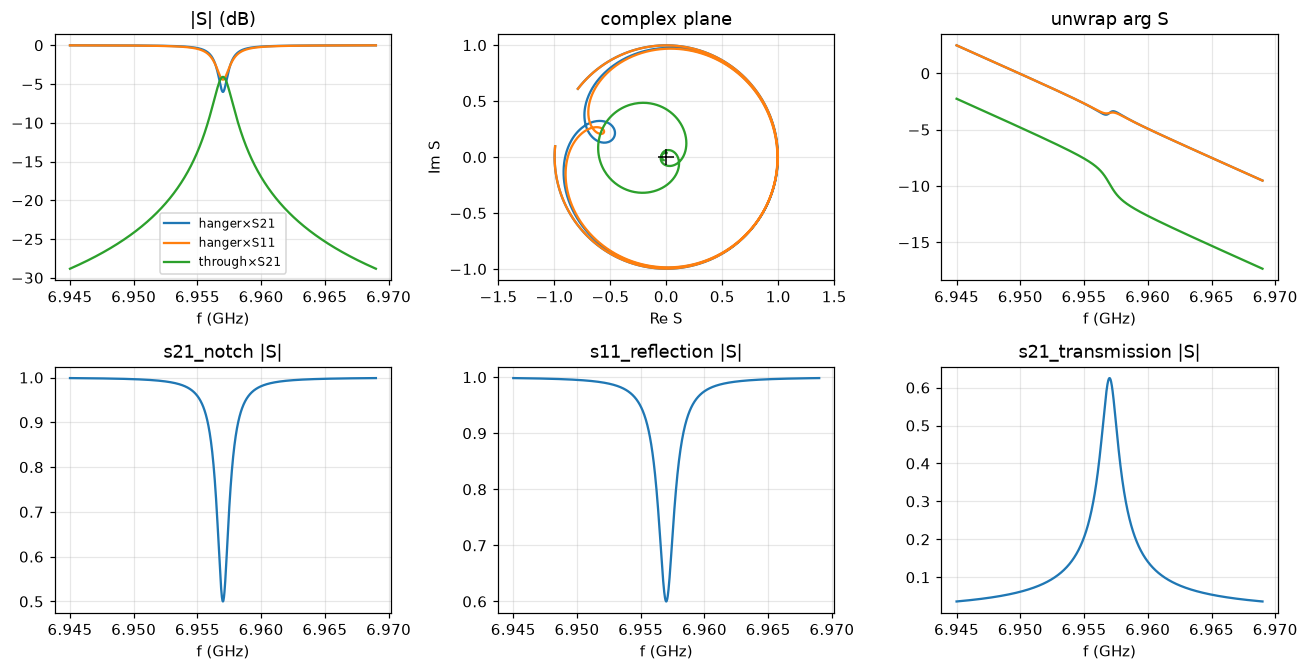

In [6]:
fr = 6.957e9
f_atlas = np.linspace(fr - 12e6, fr + 12e6, 1201)
atlas = [
    ResonatorParams(fr, 5000, 5000 / 0.5, a=1.0, tau=80e-9, layout="hanger", s_param="S21"),
    ResonatorParams(fr, 4000, 20000, a=1.0, tau=80e-9, layout="hanger", s_param="S11"),
    ResonatorParams(fr, 5000, 8000, a=1.0, tau=80e-9, layout="through", s_param="S21"),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6.2))
for p in atlas:
    s = model_s(f_atlas, p)
    lab = f"{p.layout}×{p.s_param}"
    axes[0, 0].plot(f_atlas * 1e-9, 20 * np.log10(np.abs(s) + 1e-12), label=lab)
    axes[0, 1].plot(s.real, s.imag, label=lab)
    axes[0, 2].plot(f_atlas * 1e-9, np.unwrap(np.angle(s)), label=lab)
axes[0, 0].set(title="|S| (dB)", xlabel="f (GHz)")
axes[0, 1].set(title="complex plane", xlabel="Re S", ylabel="Im S")
axes[0, 1].set_aspect("equal", adjustable="datalim")
axes[0, 1].plot(0, 0, "k+", ms=10)
axes[0, 2].set(title="unwrap arg S", xlabel="f (GHz)")
axes[0, 0].legend(fontsize=8)

# same functions without ResonatorParams, for the formula primitives
axes[1, 0].plot(f_atlas * 1e-9, np.abs(s21_notch(f_atlas, fr, 5000, 10000, tau=0)))
axes[1, 0].set(title="s21_notch |S|", xlabel="f (GHz)")
axes[1, 1].plot(f_atlas * 1e-9, np.abs(s11_reflection(f_atlas, fr, 4000, 20000, tau=0)))
axes[1, 1].set(title="s11_reflection |S|", xlabel="f (GHz)")
axes[1, 2].plot(f_atlas * 1e-9, np.abs(s21_transmission(f_atlas, fr, 5000, 8000, tau=0)))
axes[1, 2].set(title="s21_transmission |S|", xlabel="f (GHz)")
fig.tight_layout()
plt.show()


## Режимы связи

`coupling_regime(Ql, absQc, phi=0, layout=..., s_param=...)` сравнивает $\kappa_c$ и
$\kappa_i$ после DCM. Для $S_{11}$ критическая связь — $Q_l = |Q_c|/2$.


In [7]:
print("S11  Ql=5000, |Qc|=10000 →", coupling_regime(5000, 10000, layout="hanger", s_param="S11"))
print("S11  Ql=4000, |Qc|=20000 →", coupling_regime(4000, 20000, layout="hanger", s_param="S11"))
print("S11  Ql=4000, |Qc|=5000  →", coupling_regime(4000, 5000, layout="hanger", s_param="S11"))
print("hanger S21 deep dip      →", coupling_regime(5000, 5000 / 0.85, layout="hanger", s_param="S21"))


S11  Ql=5000, |Qc|=10000 → critical
S11  Ql=4000, |Qc|=20000 → undercoupled
S11  Ql=4000, |Qc|=5000  → overcoupled
hanger S21 deep dip      → overcoupled


# 5. Синтетика: `make_trace`

`make_trace(params, n, span_bw, snr, seed)` строит равномерную сетку на
`span_bw` загруженных ширин и, если задан `snr`, добавляет комплексный гаусс
с rms $= r_0/\mathrm{SNR}$ (определение Probst на радиусе круга).

Дальше все примеры — на синтетике, чтобы было видно *правду* и *восстановление*.
Три объекта ниже — три строки таблицы из §1 контракта.


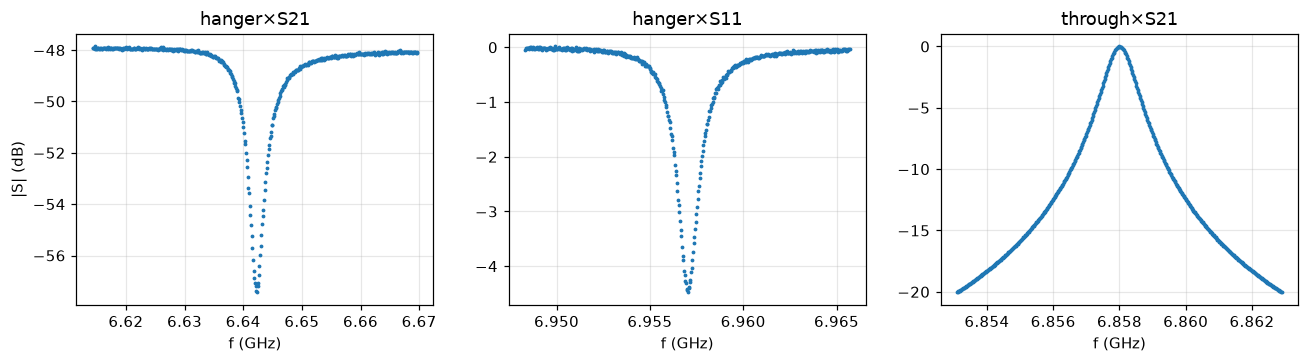

In [8]:
from sparam_fit.synthetic import make_trace

# A. вешалка, согласованный S21
true_A = ResonatorParams(
    fr=6.642e9, Ql=1200, absQc=1800, phi=0.12,
    a=0.004, alpha=0.7, tau=45e-9, layout="hanger", s_param="S21",
)
f_A, s_A = make_trace(true_A, n=501, span_bw=10.0, snr=80, seed=2)

# B. вешалка, S11 short/open, недосвязан (круг не через 0)
true_B = ResonatorParams(
    fr=6.957e9, Ql=4000, absQc=20000, phi=0.05,
    a=1.0, alpha=-0.3, tau=95e-9, layout="hanger", s_param="S11",
)
f_B, s_B = make_trace(true_B, n=501, span_bw=10.0, snr=80, seed=8)

# C. through S21 — не вешалка
true_C = ResonatorParams(
    fr=6.858e9, Ql=7000, absQc=7000, phi=0.0,
    a=1.0, alpha=0.0, tau=70e-9, layout="through", s_param="S21",
)
f_C, s_C = make_trace(true_C, n=501, span_bw=10.0, snr=None)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for axx, f, s, p in (
    (ax[0], f_A, s_A, true_A),
    (ax[1], f_B, s_B, true_B),
    (ax[2], f_C, s_C, true_C),
):
    axx.plot(f * 1e-9, 20 * np.log10(np.abs(s) + 1e-30), ".", ms=3)
    axx.set_title(f"{p.layout}×{p.s_param}")
    axx.set_xlabel("f (GHz)")
ax[0].set_ylabel("|S| (dB)")
fig.tight_layout()
plt.show()


# 6. Основные фиттеры комплексного $S$

Для **случая A** (ваши обычные hanger $S_{21}$) три независимых входа в одну модель:

| Функция | Что делает | Когда |
|---------|------------|--------|
| `fit_amp_phase` | амплитуда → фаза → комплексная полировка | основной рабочий путь |
| `fit_circle` | снятие $\tau$, круг Чернова–Лесора, $\theta(f)$, DCM, полировка | независимая проверка |
| `fit_hybrid` | оба, выбирает меньший комплексный RMS | «просто посчитай» |
| `fit_magnitude_only` | только $\|S\|$ (или дБ) | Ansys / VNA без фазы; $\tau,\alpha$ невидимы |

Почему порядок amp→phase, а не «сначала фаза»:

- $|S|$ **не зависит** от $\alpha$ и $\tau$. Подгонять их по амплитуде — отравлять $Q$.
- Сырая фаза = $-2\pi f\tau$ плюс арктангенс резонатора. Сначала снять кабель.
- $\varphi$ (Fano) **входит** в $|S|$ как асимметрия — он в амплитудном шаге.
- Остаток фазы — **круговое** расстояние `wrap(arg model − arg data)`, никогда
  `unwrap(model) − unwrap(data)` (независимые скачки $2\pi$).


In [9]:
from sparam_fit import fit_amp_phase, fit_circle, fit_hybrid, fit_magnitude_only
from sparam_fit.plots import plot_fit_report

r_ap = fit_amp_phase(f_A, s_A, layout="hanger", s_param="S21")
r_c = fit_circle(f_A, s_A, layout="hanger", s_param="S21")
best, r_ap2, r_c2 = fit_hybrid(f_A, s_A, layout="hanger", s_param="S21")
r_m = fit_magnitude_only(f_A, np.abs(s_A), layout="hanger", s_param="S21")

print("—— amp_phase ——")
print(r_ap.summary())
print("\n—— circle ——")
print(r_c.summary())
print("\n—— hybrid ——")
print(best.summary())
print("\n—— |S| only ——")
print(r_m.summary())


—— amp_phase ——
mode          : amp_phase  (amplitude → phase → complex polish)
layout        : hanger
s_param       : S21  (formula notch)
f_r           : 6.641996e+09 Hz
Q_l           : 1.198987e+03
|Q_c|         : 1.798370e+03
Q_c (DCM)     : 1.811393e+03
Q_i (DCM)     : 3.546399e+03
Q_i (no corr) : 3.597401e+03
phi           : 0.119984 rad
a, alpha, tau : 3.999898e-03,  0.708393 rad,  4.500020e-08 s
kappa_l / 2pi : 5.539673e+06 Hz  (FWHM)
kappa_i / 2pi : 1.872885e+06 Hz
kappa_c / 2pi : 3.666789e+06 Hz

—— circle ——
mode          : circle  (circle fit + optional complex polish)
layout        : hanger
s_param       : S21  (formula notch)
f_r           : 6.641996e+09 Hz
Q_l           : 1.198987e+03
|Q_c|         : 1.798370e+03
Q_c (DCM)     : 1.811393e+03
Q_i (DCM)     : 3.546399e+03
Q_i (no corr) : 3.597401e+03
phi           : 0.119984 rad
a, alpha, tau : 3.999898e-03,  0.708392 rad,  4.500020e-08 s
kappa_l / 2pi : 5.539673e+06 Hz  (FWHM)
kappa_i / 2pi : 1.872885e+06 Hz
kappa_c / 2pi

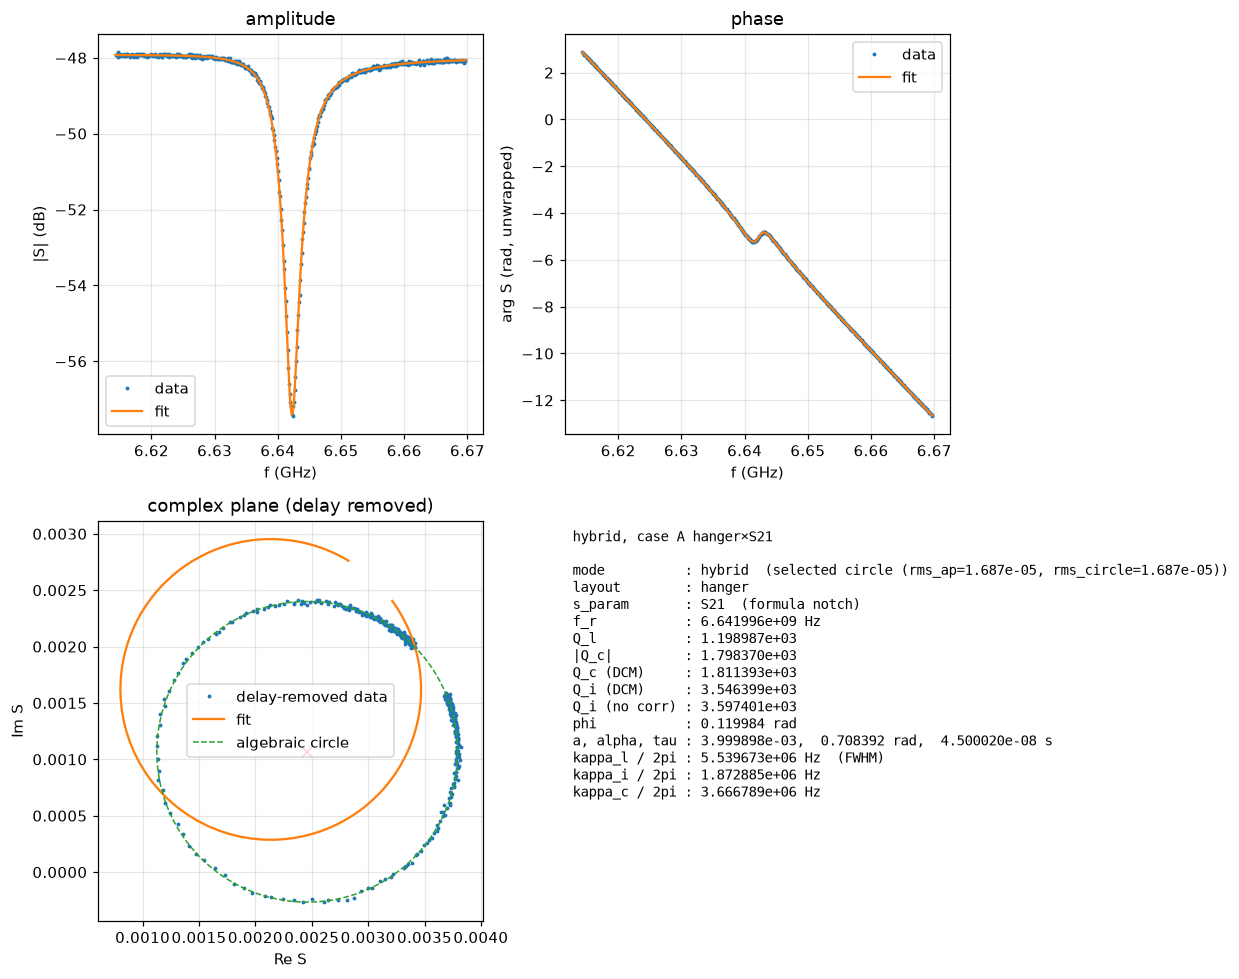

In [10]:
fig = plot_fit_report(f_A, s_A, best, title="hybrid, case A hanger×S21")
plt.show()


# 7. Диагностика полученного фита

`FitResult` — не только `params`. Смотреть нужно **всё поле**:

| Поле | Смысл |
|------|--------|
| `params` | `ResonatorParams` |
| `mode` | `circle` / `amp_phase` / `hybrid` / `magnitude` / `group_delay` |
| `success`, `message` | статус оптимизатора и человеческий комментарий |
| `diagnostics` | RMS, SNR круга, что идентифицируемо |
| `s_delay_removed` | $S$ после снятия $\tau$ — должен быть круг |
| `s_canonical` | ещё и нормировка на $a\mathrm{e}^{i\alpha}$ |
| `circle` | $(x_c,y_c,r_0)$ алгебраического круга |
| `summary()` | печать для отчёта |

Практические критерии «фит живой»:

1. `diagnostics["rms_complex"]` ≪ $a$ (для hanger S21 — доли процента от полки).
2. `fit_hybrid`: `delta_fr_hz` и `delta_Ql` малы — amp-phase и круг **согласны**.
3. После `remove_delay` локус круглый, `snr_est = r0 / std(r−r0)` большой.
4. Для magnitude-only: `tau==0`, в `not_identifiable` есть `tau`, `alpha`.
5. Для delay-only: в `not_identifiable` есть `Qi`, `Qc`; `Qi_dia_corr` — NaN.


In [11]:
from sparam_fit.models import wrap_phase
from sparam_fit.models import model_s as S_of

def diagnose_complex(name, f, s, result, true=None):
    p = result.params
    m = S_of(f, p)
    rms = np.sqrt(np.mean(np.abs(m - s) ** 2))
    rms_amp = np.sqrt(np.mean((np.abs(m) - np.abs(s)) ** 2))
    rms_ph = np.sqrt(np.mean(wrap_phase(np.angle(m) - np.angle(s)) ** 2))
    print(f"[{name}] mode={result.mode}")
    print(f"  rms complex / |S| / phase : {rms:.3e}  {rms_amp:.3e}  {rms_ph:.3e} rad")
    print(f"  diagnostics keys          : {sorted(result.diagnostics)}")
    if "snr_est" in result.diagnostics:
        print(f"  circle SNR                : {result.diagnostics['snr_est']:.1f}")
    if result.circle:
        print(f"  algebraic circle          : { {k: result.circle[k] for k in result.circle if k in ('xc','yc','r0')} }")
    if true is not None:
        print(f"  Δfr / fr                  : {(p.fr - true.fr)/true.fr:.3e}")
        print(f"  ΔQl / Ql                  : {(p.Ql - true.Ql)/true.Ql:.3e}")
        print(f"  ΔQi / Qi                  : {(p.Qi_dia_corr - true.Qi_dia_corr)/true.Qi_dia_corr:.3e}")
        print(f"  Δtau / tau                : {(p.tau - true.tau)/true.tau:.3e}")
    print()

diagnose_complex("amp_phase", f_A, s_A, r_ap, true_A)
diagnose_complex("circle",    f_A, s_A, r_c,  true_A)
diagnose_complex("hybrid",    f_A, s_A, best, true_A)
print("hybrid deltas:", {k: best.diagnostics[k] for k in ("delta_fr_hz", "delta_Ql", "delta_Qi", "rms_amp_phase", "rms_circle")})
print("|S|-only identifiable    :", r_m.diagnostics["identifiable"])
print("|S|-only not identifiable:", r_m.diagnostics["not_identifiable"])


[amp_phase] mode=amp_phase
  rms complex / |S| / phase : 1.687e-05  1.215e-05  3.459e-03 rad
  diagnostics keys          : ['amp_cost', 'rms_amp', 'rms_complex', 'rms_phase']
  algebraic circle          : {'xc': 0.002136092327346258, 'yc': 0.0016199094615477285, 'r0': 0.0013335957194793011}
  Δfr / fr                  : -6.182e-07
  ΔQl / Ql                  : -8.442e-04
  ΔQi / Qi                  : -7.207e-04
  Δtau / tau                : 4.467e-06

[circle] mode=circle
  rms complex / |S| / phase : 1.687e-05  1.215e-05  3.459e-03 rad
  diagnostics keys          : ['rms_complex', 'snr_est']
  circle SNR                : 111.2
  algebraic circle          : {'xc': 0.0024657468884151943, 'yc': 0.0010516235540262377, 'r0': 0.0013331660998384472}
  Δfr / fr                  : -6.182e-07
  ΔQl / Ql                  : -8.442e-04
  ΔQi / Qi                  : -7.207e-04
  Δtau / tau                : 4.466e-06

[hybrid] mode=hybrid
  rms complex / |S| / phase : 1.687e-05  1.215e-05  3.459e-03

Картина остатков. Комплексный остаток должен быть шумом без резонансной «структуры».
Фазовый остаток — через `wrap_phase`, не через разность unwrap.


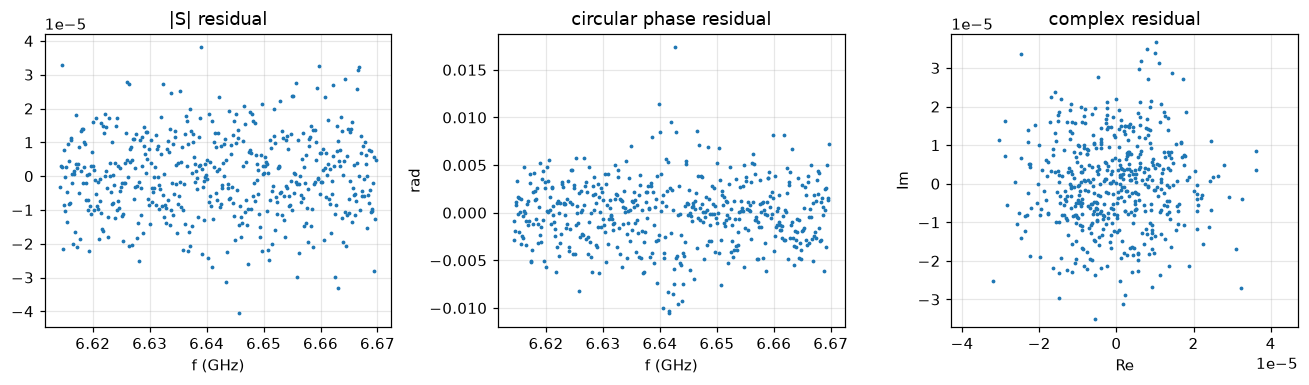

In [12]:
m = S_of(f_A, best.params)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].plot(f_A * 1e-9, np.abs(s_A) - np.abs(m), ".", ms=3)
axes[0].set(title="|S| residual", xlabel="f (GHz)")
axes[1].plot(f_A * 1e-9, wrap_phase(np.angle(m) - np.angle(s_A)), ".", ms=3)
axes[1].set(title="circular phase residual", xlabel="f (GHz)", ylabel="rad")
axes[2].plot((s_A - m).real, (s_A - m).imag, ".", ms=3)
axes[2].set(title="complex residual", xlabel="Re", ylabel="Im")
axes[2].set_aspect("equal", adjustable="datalim")
fig.tight_layout()
plt.show()


# 8. Вспомогательные методы: кабель, guess, круг

Эти функции **не** главный API, но ими диагностируют пайплайн Probst по шагам.
Если hybrid «поехал», почти всегда виноват $\tau$ или старт по $|S|$.


true tau     = 4.500000e-08 s
linear guess = 4.441699e-08 s   (fr~6.642332e+09, Ql~1224.6)
circle refine= 4.499432e-08 s
fit_delay    = 4.499432e-08 s


guess_from_magnitude: {'fr': 6642332100.0, 'Ql': 1224.5510204081634, 'a': 0.003983175010005005, 'depth': 0.0013435194605970642, 'is_notch': np.True_, 'fwhm': 5424300.0}
Chernov–Lesort circle: xc=0.002466, yc=0.001052, r0=0.001333, chi2=1.437e-10


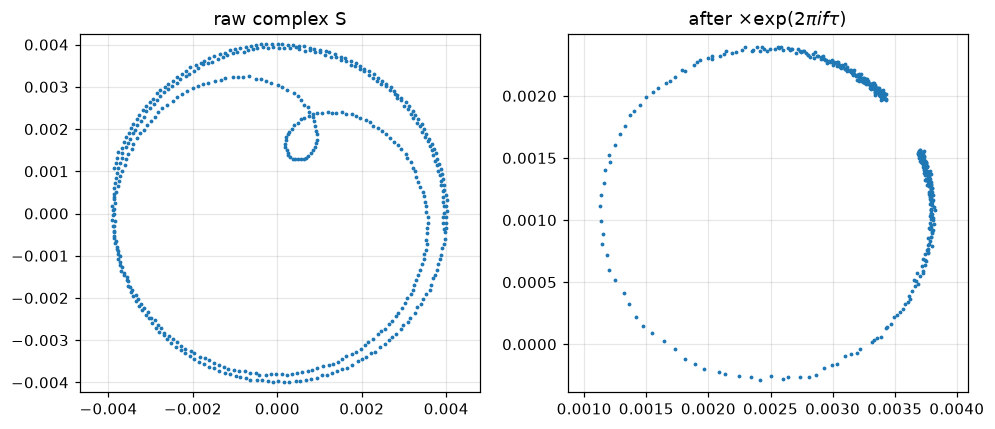

In [13]:
from sparam_fit.circle import circle_chi2, fit_circle_algebraic
from sparam_fit.guess import (
    guess_delay_linear,
    guess_from_magnitude,
    refine_delay_circle,
    remove_delay,
)
from sparam_fit.fit import fit_delay
from sparam_fit.plots import plot_delay_before_after

tau0, fr_guess, Ql_guess = guess_delay_linear(f_A, s_A)
tau_ref = refine_delay_circle(f_A, s_A, tau0)
tau_fit, z = fit_delay(f_A, s_A)  # linear guess + circular refine
print(f"true tau     = {true_A.tau:.6e} s")
print(f"linear guess = {tau0:.6e} s   (fr~{fr_guess:.6e}, Ql~{Ql_guess:.1f})")
print(f"circle refine= {tau_ref:.6e} s")
print(f"fit_delay    = {tau_fit:.6e} s")

gmag = guess_from_magnitude(f_A, np.abs(s_A))
print("guess_from_magnitude:", {k: (float(v) if isinstance(v, (float, np.floating)) else v) for k, v in gmag.items()})

xc, yc, r0 = fit_circle_algebraic(z, refine=True)
print(f"Chernov–Lesort circle: xc={xc:.4g}, yc={yc:.4g}, r0={r0:.4g}, chi2={circle_chi2(z, xc, yc, r0):.3e}")

fig = plot_delay_before_after(f_A, s_A, tau_fit)
plt.show()


`wrap_phase` отображает угол в $(-\pi,\pi]$. Им сравнивают фазы модели и данных.


In [14]:
angles = np.array([-3.5, -np.pi, 0.0, np.pi, 3.5, 8.0])
print("raw  ", angles)
print("wrap ", wrap_phase(angles))


raw   [-3.5        -3.14159265  0.          3.14159265  3.5         8.        ]
wrap  [ 2.78318531 -3.14159265  0.          3.14159265 -2.78318531  1.71681469]


# 9. Случай B — hanger × S11 (short/open)

Та же вешалка, но дальний конец фидера замкнут или холостой. Вблизи одного
режима $S_{11}$ — формула one-port. Круг-фит берёт **другой** закон радиуса:
$|Q_c|=Q_l/r_0$, не $Q_l/(2r_0)$.


mode          : circle  (circle fit + optional complex polish)
layout        : hanger
s_param       : S11  (formula reflection)
f_r           : 6.956999e+09 Hz
Q_l           : 4.010569e+03
|Q_c|         : 2.002902e+04
Q_c (DCM)     : 2.005483e+04
Q_i (DCM)     : 5.013087e+03
Q_i (no corr) : 5.014702e+03
phi           : 0.050741 rad
a, alpha, tau : 9.998131e-01,  -0.339007 rad,  9.499911e-08 s
kappa_l / 2pi : 1.734666e+06 Hz  (FWHM)
kappa_i / 2pi : 1.387768e+06 Hz
kappa_c / 2pi : 3.468989e+05 Hz

[hanger S11 circle] mode=circle
  rms complex / |S| / phase : 2.528e-03  1.839e-03  1.870e-03 rad
  diagnostics keys          : ['rms_complex', 'snr_est']
  circle SNR                : 111.1
  algebraic circle          : {'xc': 0.24917488797327586, 'yc': 0.7603063672233205, 'r0': 0.2003670727432245}
  Δfr / fr                  : -1.590e-07
  ΔQl / Ql                  : 2.642e-03
  ΔQi / Qi                  : 2.931e-03
  Δtau / tau                : -9.403e-06



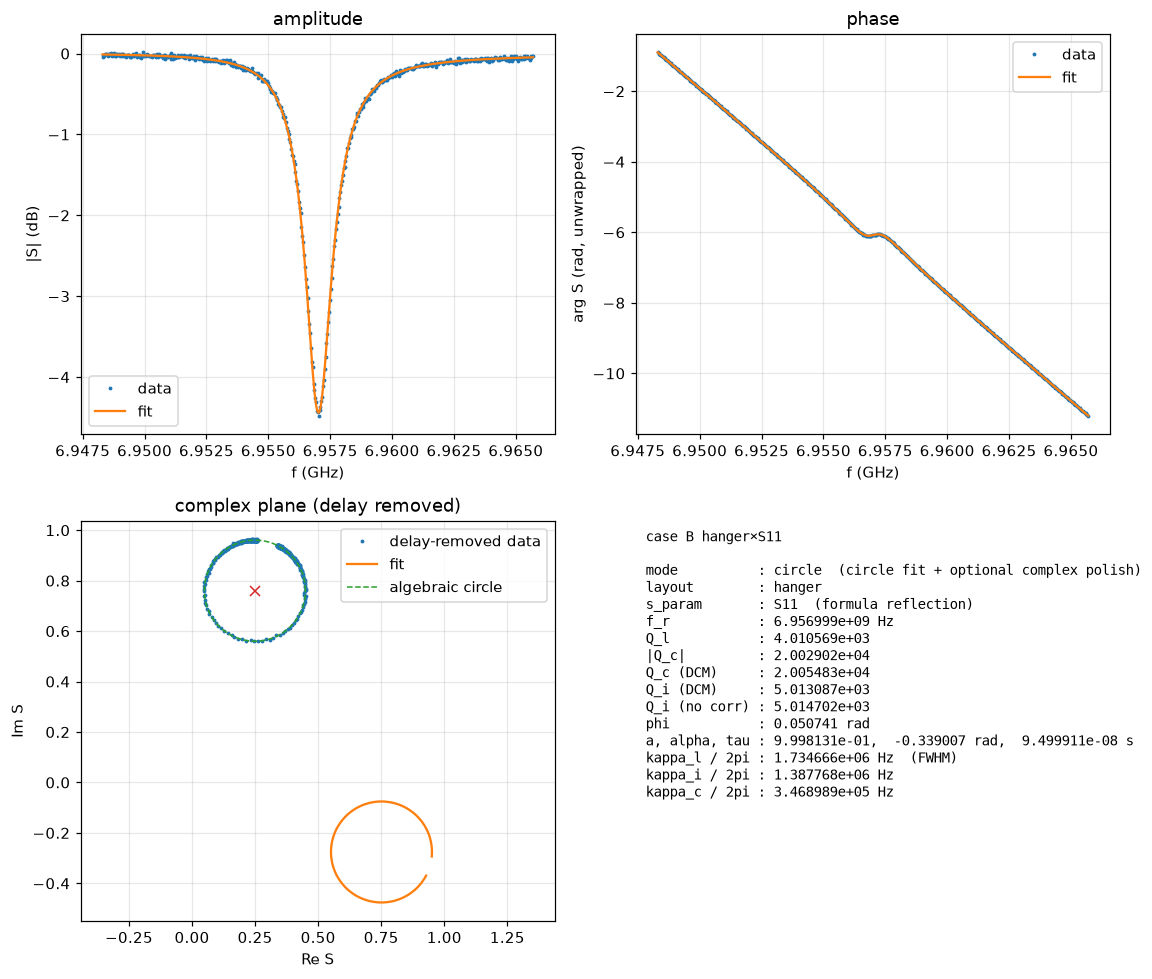

In [15]:
r_B = fit_circle(f_B, s_B, layout="hanger", s_param="S11")
print(r_B.summary())
print()
diagnose_complex("hanger S11 circle", f_B, s_B, r_B, true_B)
fig = plot_fit_report(f_B, s_B, r_B, title="case B hanger×S11")
plt.show()


# 10. Групповая задержка

`group_delay_from_s(f, s)` — IEEE $\tau_g$ из комплексного $S$
(`analytic_diff` или `unwrap`).  
`group_delay_model(f, params)` — аналитическая производная **уже выбранной**
формулы $S$; это оверлей, **не** delay-фиттер.  
`delay_lorentzian` — феноменология одного полюса.  
`phase_from_group_delay` — интеграл $\tau_g\to\arg S$ (амплитуда не восстанавливается).  
`group_delay_peak_scale(fr, Ql) = Q_l/(\pi f_r)` — высота пика through-линии.


median |numeric − analytic| / |tau|  (hanger S21): 0.04625918694716678
through extra delay at fr / (Ql/πfr): 1.0


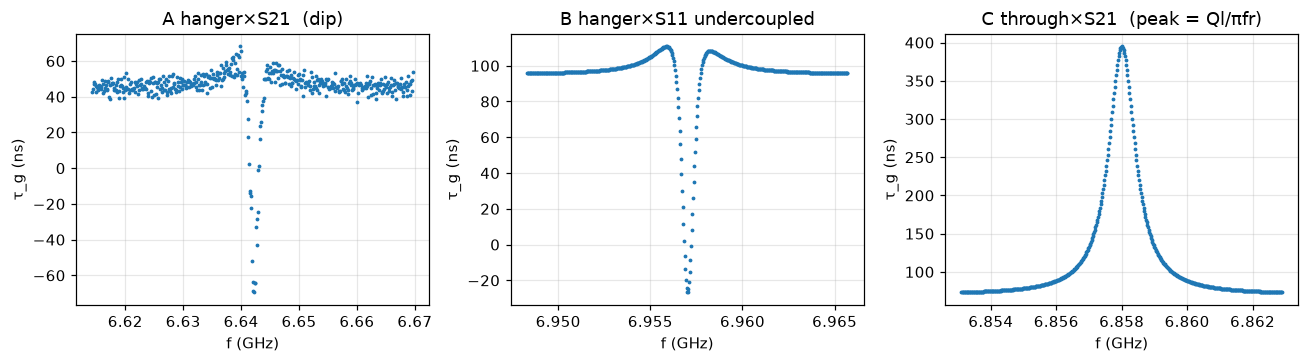

In [16]:
from sparam_fit.group_delay import (
    delay_lorentzian,
    group_delay_from_s,
    group_delay_model,
    group_delay_peak_scale,
    guess_from_group_delay,
    orient_delay_sweep,
    phase_from_group_delay,
)

# IEEE delay of the three cases
tg_A = group_delay_from_s(f_A, s_A)
tg_A_an = group_delay_model(f_A, true_A)
tg_B = group_delay_model(f_B, true_B)
tg_C = group_delay_model(f_C, true_C)

print("median |numeric − analytic| / |tau|  (hanger S21):",
      np.nanmedian(np.abs(tg_A - tg_A_an)) / abs(true_A.tau))
print("through extra delay at fr / (Ql/πfr):",
      (tg_C[len(f_C)//2] - true_C.tau) / group_delay_peak_scale(true_C.fr, true_C.Ql))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4), sharey=False)
for axx, f, tg, title in (
    (ax[0], f_A, tg_A, "A hanger×S21  (dip)"),
    (ax[1], f_B, tg_B, "B hanger×S11 undercoupled"),
    (ax[2], f_C, tg_C, "C through×S21  (peak = Ql/πfr)"),
):
    axx.plot(f * 1e-9, tg * 1e9, ".", ms=3)
    axx.set(title=title, xlabel="f (GHz)", ylabel="τ_g (ns)")
fig.tight_layout()
plt.show()


Интеграл задержки даёт фазу с точностью до константы $\alpha$. Модуль $S$ из
$\tau_g$ **не** достать — поэтому delay-only не имеет права печатать $Q_i$.


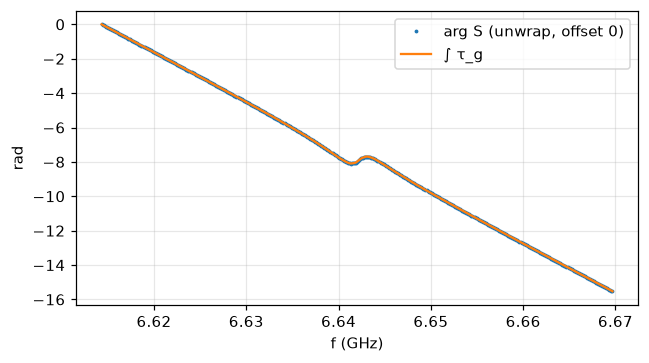

In [17]:
phase_rec = phase_from_group_delay(f_A, tg_A, alpha=0.0)
phase_true = np.unwrap(np.angle(s_A))
# вычесть линейный/константный остаток на краях, сравнить форму резонатора
phase_true = phase_true - phase_true[0]
phase_rec = phase_rec - phase_rec[0]
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(f_A * 1e-9, phase_true, ".", ms=3, label="arg S (unwrap, offset 0)")
ax.plot(f_A * 1e-9, phase_rec, "-", label="∫ τ_g")
ax.set(xlabel="f (GHz)", ylabel="rad")
ax.legend()
fig.tight_layout()
plt.show()


## `fit_group_delay` — всегда лоренциан

Никакого `model="auto"`, никакой подмены notch↔reflection. На выходе $f_r$, $Q_l$,
$\tau$, амплитуда пика $A$, наклон полки. $Q_i$ — NaN.

Для карт 53672 (полка ~95 ns + пик) это правильный инструмент.
Ширина delay-пика $S_{11}$ **не обязана** совпадать с $Q_l$ из круга: у
недосвязанного $S_{11}$ задержка даже отрицательная (аномальная дисперсия),
у пересвязанного — пик, у критического — расходимость. Поэтому $Q_l$ из delay
есть ширина **этой** $\tau_g$-кривой, а не автоматически $Q_l$ круга.


mode          : group_delay  (lorentzian delay; Q_c/Q_i are not identified; amp/amp_through=0.999 (1 ≈ through S21 peak))
layout/s_param: not identified from delay-only data
f_r           : 6.957130e+09 Hz
Q_l           : 5.993419e+03
tau (cable)   : 9.492837e-08 s
amp (peak)    : 2.739074e-07 s
slope         : -2.982180e-17 s/Hz
kappa_l / 2pi : 1.160795e+06 Hz  (FWHM)
Q_i / Q_c     : not identified from delay-only data
identifiable    : ['fr', 'Ql', 'tau', 'slope', 'amp']
not identifiable: ['Qc', 'Qi', 'a', 'alpha', 'layout']
Qi_dia_corr is finite? False
guess_from_group_delay: {'fr': 6957120000.0, 'Ql': 6368.073226544622, 'amp': 2.7684501774606236e-07, 'baseline': 9.585210048050408e-08, 'peak_is_positive': np.True_}


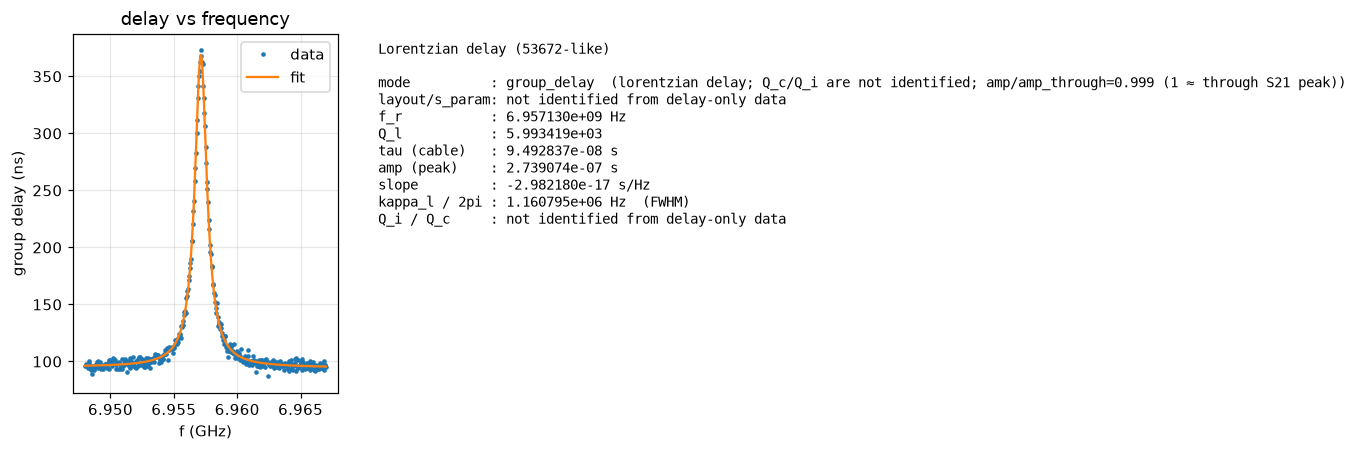

In [18]:
from sparam_fit import fit_group_delay, fit_group_delay_vs_power
from sparam_fit.plots import plot_group_delay_fit, plot_delay_power_map

# как 53672: чистый лоренциан на кабельной полке
fr_d, Ql_d, tau_d = 6.95713e9, 6000.0, 95e-9
f_d = np.linspace(6.948e9, 6.967e9, 401)
amp_d = Ql_d / (np.pi * fr_d)
tg_d = delay_lorentzian(f_d, fr_d, Ql_d, tau_d, amp=amp_d)
tg_d = tg_d + 3e-9 * np.random.default_rng(0).normal(size=f_d.size)

r_d = fit_group_delay(f_d, tg_d)
print(r_d.summary())
print("identifiable    :", r_d.diagnostics["identifiable"])
print("not identifiable:", r_d.diagnostics["not_identifiable"])
print("Qi_dia_corr is finite?", np.isfinite(r_d.params.Qi_dia_corr))
print("guess_from_group_delay:", {k: guess_from_group_delay(f_d, tg_d)[k] for k in ("fr", "Ql", "amp", "baseline", "peak_is_positive")})

fig = plot_group_delay_fit(f_d, tg_d, r_d, title="Lorentzian delay (53672-like)")
plt.show()


Старые аргументы `geometry=`, `model=`, `sign=` **игнорируются** (warning).
Фиттер не переключится на производную $S_{11}$ и не поднимет полку, как в
неудачных оверлеях на реальных картах.


In [19]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    r_ignored = fit_group_delay(f_d, tg_d, geometry="notch", model="sparam")
print("still lorentzian:", r_ignored.diagnostics["model"])
print("warning:", caught[0].message if caught else "none")


still lorentzian: lorentzian


Hanger $S_{21}$ даёт **отрицательную** добавку к $\tau_g$. Лоренциан это видит
(`amp_s < 0`) и находит $f_r$, но $Q_l$ delay-ширины ≠ $Q_l$ круга — это не баг,
а другая наблюдаемая.


In [20]:
r_dip = fit_group_delay(f_A, tg_A)
print(r_dip.summary())
print("amp_s (must be < 0 for hanger S21):", r_dip.diagnostics["amp_s"])
print("fr recovered:", r_dip.params.fr, "  true:", true_A.fr)


mode          : group_delay  (lorentzian delay; Q_c/Q_i are not identified; amp/amp_through=-0.428 (1 ≈ through S21 peak))
layout/s_param: not identified from delay-only data
f_r           : 6.642234e+09 Hz
Q_l           : 6.169192e+03
tau (cable)   : 4.845447e-08 s
amp (peak)    : -1.265146e-07 s
slope         : -7.822042e-19 s/Hz
kappa_l / 2pi : 1.076678e+06 Hz  (FWHM)
Q_i / Q_c     : not identified from delay-only data
amp_s (must be < 0 for hanger S21): -1.2651457789113477e-07
fr recovered: 6642234016.1194725   true: 6642000000.0


## Карта delay vs мощность и `orient_delay_sweep`

`fit_group_delay_vs_power(f, power, delay_2d)` — лоренциан на каждом срезе.
`Qi` в массиве — NaN.  
`orient_delay_sweep(p0, p1, data)` переставляет оси exdir-стиля, если частота
и мощность перепутаны местами.


Ql vs power: [(np.float64(-50.0), np.float64(5000.0)), (np.float64(-30.0), np.float64(6000.0)), (np.float64(-10.0), np.float64(7000.0))]
Qi all NaN?: True


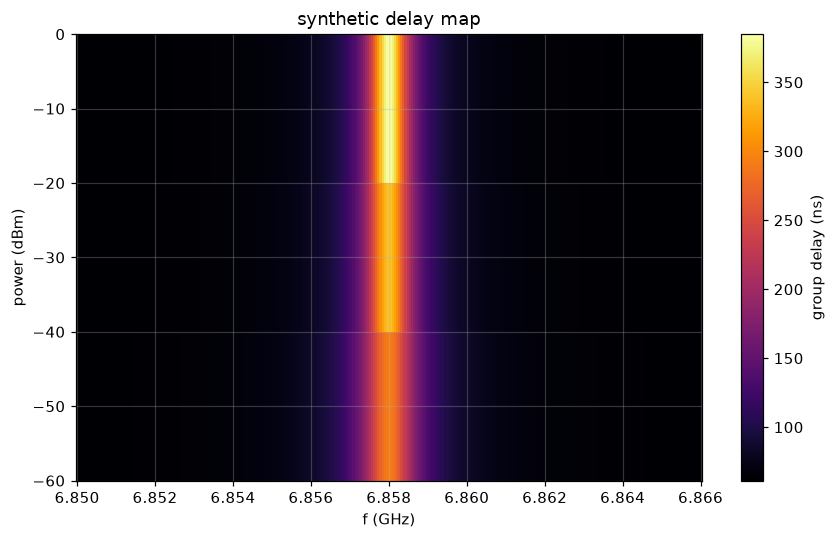

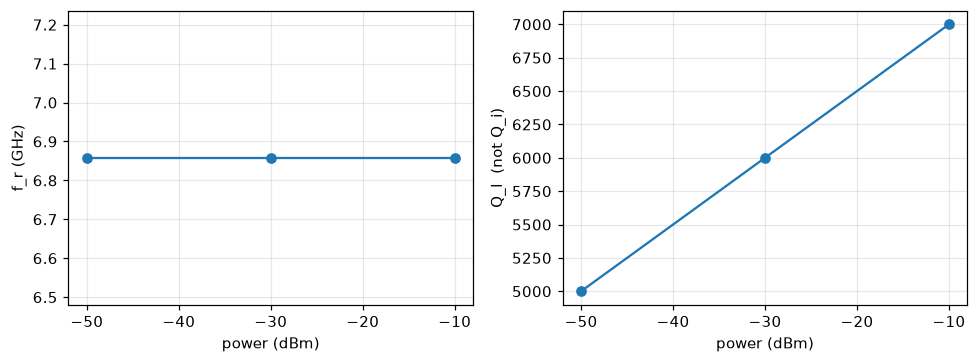

In [21]:
powers = np.array([-50.0, -30.0, -10.0])
f_map = np.linspace(6.85e9, 6.866e9, 301)
rows = []
for Ql in (5000, 6000, 7000):
    rows.append(delay_lorentzian(f_map, 6.858e9, Ql, 60e-9, amp=Ql / (np.pi * 6.858e9)))
delay_2d = np.vstack(rows)

# оси перепутаны — как иногда приходит из exdir
f_ok, p_ok, z_ok = orient_delay_sweep(powers, f_map, delay_2d.T)
assert np.allclose(f_ok, f_map) and z_ok.shape == (3, 301)

results, arr = fit_group_delay_vs_power(f_map, powers, delay_2d)
print("Ql vs power:", list(zip(arr["power"], arr["Ql"])))
print("Qi all NaN?:", np.all(~np.isfinite(arr["Qi"])))

fig = plot_delay_power_map(f_map, powers, delay_2d, title="synthetic delay map")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(arr["power"], arr["fr"] * 1e-9, "o-")
ax[0].set(xlabel="power (dBm)", ylabel="f_r (GHz)")
ax[1].plot(arr["power"], arr["Ql"], "o-")
ax[1].set(xlabel="power (dBm)", ylabel="Q_l  (not Q_i)")
fig.tight_layout()
plt.show()


# 11. Случай C — through $S_{21}$

Резонатор *есть* путь. Полка вне резонанса ≈ 0, пик на $f_r$. $a$ и $|Q_c|$
вырождены, $Q_i$ из некалиброванного $S_{21}$ **не** заслуживает доверия.
Не используйте этот layout для вешалок.

`fit_magnitude_only` **не** переименует пик в through сам — layout задаёте вы.


In [22]:
r_C = fit_magnitude_only(f_C, np.abs(s_C), layout="through", s_param="S21")
print(r_C.summary())
print("not identifiable:", r_C.diagnostics["not_identifiable"])
print("fr, Ql recovered:", r_C.params.fr, r_C.params.Ql)

# молчаливого авто-switch нет: пик, но caller сказал hanger
r_wrong_label = fit_magnitude_only(f_C, np.abs(s_C), layout="hanger", s_param="S21")
print("still labeled", r_wrong_label.params.layout, r_wrong_label.params.s_param)


mode          : magnitude  (through |S|: a and |Qc| are degenerate; Qi from DCM is not trustworthy; tau and alpha cannot be recovered from magnitude alone)
layout        : through
s_param       : S21  (formula through)
f_r           : 6.858000e+09 Hz
Q_l           : 7.000000e+03
|Q_c|         : 6.528193e+03
Q_c (DCM)     : 6.646275e+03
Q_i (DCM)     : -1.315256e+05
Q_i (no corr) : -9.685596e+04
phi           : 0.188783 rad
a, alpha, tau : 9.325990e-01,  0.000000 rad,  0.000000e+00 s
kappa_l / 2pi : 9.797143e+05 Hz  (FWHM)
kappa_i / 2pi : -5.214195e+04 Hz
kappa_c / 2pi : 1.031856e+06 Hz
not identifiable: ['tau', 'alpha', 'Qi']
fr, Ql recovered: 6858000000.0 6999.999999999999
still labeled hanger S21


# 12. Что из каких данных видно

| Наблюдаемая | Видно | Не видно |
|-------------|-------|----------|
| комплексный hanger $S_{21}$ | $f_r,Q_l,|Q_c|,\varphi,a,\alpha,\tau,Q_i$ (DCM) | — |
| комплексный hanger $S_{11}$ | то же, с законом круга $S_{11}$ | не путать с согласованным $S_{11}\approx 0$ off-res |
| только $|S|$ | $f_r,Q_l,\varphi,a,|Q_c|$ (hanger) | $\tau,\alpha$; у through ещё $Q_i$ |
| только $\tau_g$ | $f_r,Q_l,\tau,A,s$ | $|S|,a,\alpha,Q_c,Q_i$, layout |

Over/under **нельзя** прочитать по высоте delay-пика без $|S|$.


# 13. Графики и чтение файлов

| Функция | Рисунок |
|---------|---------|
| `plot_fit_report(f, s, result)` | $\|S\|$, фаза, круг, текст `summary` |
| `plot_delay_before_after(f, s, tau)` | сырой локус vs после снятия кабеля |
| `plot_group_delay_fit(f, tau_g, result)` | трасса delay + лоренциан |
| `plot_delay_power_map(f, power, delay_2d)` | тепловая карта |

`load_two_column_complex(path, freq_unit="Hz"|"MHz"|"GHz")` читает CSV
`f, Re, Im` или `f, dB, deg` (эвристика по диапазону первой колонки данных).


In [23]:
import tempfile
from sparam_fit.synthetic import load_two_column_complex

csv_path = Path(tempfile.gettempdir()) / "sparam_tour_demo.csv"
np.savetxt(
    csv_path,
    np.column_stack([f_A, s_A.real, s_A.imag]),
    delimiter=",",
)
f_io, s_io = load_two_column_complex(csv_path, freq_unit="Hz")
print("loaded", f_io.shape, "  max |ΔS| vs original", np.max(np.abs(s_io - s_A)))


loaded (501,)   max |ΔS| vs original 1.0034584835426223


# 14. Шпаргалка по вашим чипам

```python
from sparam_fit import (
    fit_hybrid, fit_circle, fit_amp_phase, fit_magnitude_only,
    fit_group_delay, fit_group_delay_vs_power,
)

# A. вешалка, оба порта 50 Ω, комплексный S21
best, r_ap, r_c = fit_hybrid(freq_hz, s21, layout="hanger", s_param="S21")
print(best.summary())

# B. та же вешалка, дальний конец short/open, комплексный S11
r_s11 = fit_circle(freq_hz, s11, layout="hanger", s_param="S11")

# B. VNA Delay / qsweepy карта 53672 — только лоренциан, без Qi
r_d = fit_group_delay(freq_hz, tau_g_s)
results, vs_p = fit_group_delay_vs_power(freq_hz, power_dBm, delay_2d)

# C. in-line резонатор (не вешалка)
r_m = fit_magnitude_only(freq_hz, mag, layout="through", s_param="S21")
```

Диагностический минимум после каждого фита:

1. `print(result.summary())`
2. `plot_fit_report` или `plot_group_delay_fit`
3. остатки без резонансной структуры
4. для hybrid — малые `delta_fr_hz`, `delta_Ql`
5. не верить $Q_i$, если в `not_identifiable` есть `Qi` или `Qi_dia_corr` — NaN

Частоты — в герцах. $Q = f/\mathrm{FWHM}$. Вешалку не описывать как `through`.
